# MC Calibration Backtest — score vs score_smooth

Compares two Monte Carlo ranking-signal variants over the 2025-11-04 → present window:

- **`score`**         : `score * 10000 + tiebreak` (current production default)
- **`score_smooth`**  : `score`-composite pool with N(0, 0.5 pts) Gaussian noise added to each sampled score

Both variants share the same attendance model (EWMA over the 2025-09-02+ single-session era),
the same simulation kernel, and the same player pool (both use `build_player_pool_score`).
The only difference is the Gaussian noise added to per-player, per-sim signals before ranking.

Predictions and outcomes live in the `backtest` table populated by
`scripts/run_backtest.py`. Row = (tourn_date, model, username).

In [1]:
import sys, sqlite3
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import DB_PATH

pd.set_option('display.max_rows', 200)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

N_VALUES = [1, 3, 5, 8, 10]

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    df = pd.read_sql_query('SELECT * FROM backtest', conn, parse_dates=['tourn_date'])

# Marginal P(top-N) = p_participate * P(top-N | play)
for k in N_VALUES:
    df[f'P_top{k}'] = df['p_participate'] * df[f'P_top{k}_given_play']

# Actual top-N outcome (1 if player played and finished with rank <= k)
for k in N_VALUES:
    df[f'in_top{k}'] = ((df['played'] == 1) & (df['actual_rank'] <= k)).astype(int)

print(f"{len(df):,} rows | {df['tourn_date'].nunique()} tournaments | models={df['model'].unique().tolist()}")
df.groupby('model').size().rename('rows').to_frame()

1,168,618 rows | 47 tournaments | models=['score', 'perf', 'score_smooth', 'score_smooth_narrow']


,rows
model,
perf,216011
score,308067
score_smooth,322270
score_smooth_narrow,322270


In [3]:
# Metric helpers used throughout the notebook.

def brier(p, y):
    return float(np.mean((p - y) ** 2))

def log_loss(p, y, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

def rows_metrics(sub, col_p, col_y):
    return {
        'n': len(sub),
        'base_rate': float(sub[col_y].mean()),
        'mean_pred': float(sub[col_p].mean()),
        'brier': brier(sub[col_p].to_numpy(), sub[col_y].to_numpy()),
        'log_loss': log_loss(sub[col_p].to_numpy(), sub[col_y].to_numpy()),
    }

In [4]:
# Reliability-curve helper used by the calibration plots below.

def cal_curve(p, y, bins=None):
    if bins is None:
        bins = [0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 0.35, 0.50, 0.70, 1.0]
    b = np.digitize(p, bins) - 1
    b = np.clip(b, 0, len(bins) - 2)
    out = []
    for i in range(len(bins) - 1):
        m = b == i
        if m.sum() > 0:
            out.append({
                'bin_lo': bins[i], 'bin_hi': bins[i+1],
                'n': int(m.sum()),
                'mean_pred': float(p[m].mean()),
                'emp_rate': float(y[m].mean()),
            })
    return pd.DataFrame(out)

In [5]:
# Tie-safe ROC-AUC (Mann-Whitney U form) used by the ranking plots below.
from scipy.stats import rankdata

def _auc(p, y):
    """Mann-Whitney U form of ROC-AUC, tie-safe via fractional ranks."""
    y = np.asarray(y); p = np.asarray(p)
    pos = int(y.sum()); neg = len(y) - pos
    if pos == 0 or neg == 0:
        return np.nan
    r = rankdata(p)  # ascending; ties get mean rank
    r_pos = r[y == 1].sum()
    return float((r_pos - pos * (pos + 1) / 2) / (pos * neg))

# Score vs Gaussian-Smoothed Variants

Two smoothed variants share `build_player_pool_score` with `score` — same eligibility filter, same sampled historical scores, same `p_participate` — differing only in the σ of the Gaussian noise added to each per-player, per-sim signal before ranking:

- **`score`**                — no smoothing (σ = 0)
- **`score_smooth`**         — σ = 5000 composite units = 0.5 score-pts (`SCORE_GAUSSIAN_KERNEL_SIGMA_WIDE`); smooths across whole score buckets
- **`score_smooth_narrow`**  — σ = 100 composite units, ≈ 2× tiebreak magnitude (`SCORE_GAUSSIAN_KERNEL_SIGMA_NARROW`); smooths tiebreak noise while keeping score-rank ordering intact

Because all three come from the same pool builder, no intersection view is needed. Attendance calibration is identical (same `p_participate`); the interesting comparison is the top-N calibration.

In [6]:
# Restrict to the score-family triple. Fixed colour map used by every plot below.
SMOOTH_MODELS = ('score', 'score_smooth', 'score_smooth_narrow')
MODEL_COLORS  = {'score': 'C0', 'score_smooth': 'C2', 'score_smooth_narrow': 'C3'}

df_sm = df[df['model'].isin(SMOOTH_MODELS)].copy()

# Sanity check: identical pools per tournament across all three variants
pool_check = df_sm.groupby(['tourn_date', 'model']).size().unstack('model')
pool_check['delta_smooth']        = pool_check['score_smooth']        - pool_check['score']
pool_check['delta_smooth_narrow'] = pool_check['score_smooth_narrow'] - pool_check['score']
print(f"Rows: {len(df_sm):,} | tournaments: {df_sm['tourn_date'].nunique()}")
print('Per-tournament pool size:')
print(pool_check.describe().round(0))
if (pool_check[['delta_smooth', 'delta_smooth_narrow']].abs().to_numpy().sum()) != 0:
    print('WARN: pool sizes differ across score-family models')

Rows: 952,607 | tournaments: 47
Per-tournament pool size:
model   score  score_smooth  score_smooth_narrow  delta_smooth  \
count    45.0          47.0                 47.0          45.0   
mean   6846.0        6857.0               6857.0           0.0   
std     131.0         139.0                139.0           0.0   
min    6646.0        6646.0               6646.0           0.0   
25%    6740.0        6744.0               6744.0           0.0   
50%    6833.0        6840.0               6840.0           0.0   
75%    6943.0        6963.0               6963.0           0.0   
max    7085.0        7106.0               7106.0           0.0   

model  delta_smooth_narrow  
count                 45.0  
mean                   0.0  
std                    0.0  
min                    0.0  
25%                    0.0  
50%                    0.0  
75%                    0.0  
max                    0.0  
WARN: pool sizes differ across score-family models


## Top-N calibration: Brier + log-loss

Same metric functions as above (`rows_metrics`, `brier`, `log_loss`), applied to marginal `P_top{N}` and conditional `P_top{N}_given_play`.

In [7]:
rows_sm = []
for k in N_VALUES:
    for m in SMOOTH_MODELS:
        sub = df_sm[df_sm['model'] == m]
        rows_sm.append({'metric': 'marginal', 'N': k, 'model': m,
                        **rows_metrics(sub, f'P_top{k}', f'in_top{k}')})
        play = sub[sub['played'] == 1]
        rows_sm.append({'metric': 'given_play', 'N': k, 'model': m,
                        **rows_metrics(play, f'P_top{k}_given_play', f'in_top{k}')})

metrics_sm = pd.DataFrame(rows_sm)

brier_sm = (metrics_sm
            .pivot_table(index=['metric', 'N'], columns='model', values='brier'))
brier_sm = brier_sm[list(SMOOTH_MODELS)]  # column order
brier_sm['best'] = brier_sm.idxmin(axis=1)

logloss_sm = (metrics_sm
              .pivot_table(index=['metric', 'N'], columns='model', values='log_loss'))
logloss_sm = logloss_sm[list(SMOOTH_MODELS)]
logloss_sm['best'] = logloss_sm[list(SMOOTH_MODELS)].idxmin(axis=1)

print('Brier (lower is better):')
print(brier_sm.round(6))
print()
print('Log-loss (lower is better):')
print(logloss_sm.round(6))

Brier (lower is better):
model             score  score_smooth  score_smooth_narrow          best
metric     N                                                            
given_play 1   0.002702      0.002662             0.002687  score_smooth
           3   0.007235      0.007220             0.007265  score_smooth
           5   0.011689      0.011621             0.011750  score_smooth
           8   0.017174      0.017140             0.017382  score_smooth
           10  0.020808      0.020760             0.021093  score_smooth
marginal   1   0.000141      0.000140             0.000140  score_smooth
           3   0.000391      0.000394             0.000393         score
           5   0.000639      0.000642             0.000641         score
           8   0.000968      0.000977             0.000974         score
           10  0.001192      0.001201             0.001198         score

Log-loss (lower is better):
model             score  score_smooth  score_smooth_narrow          be

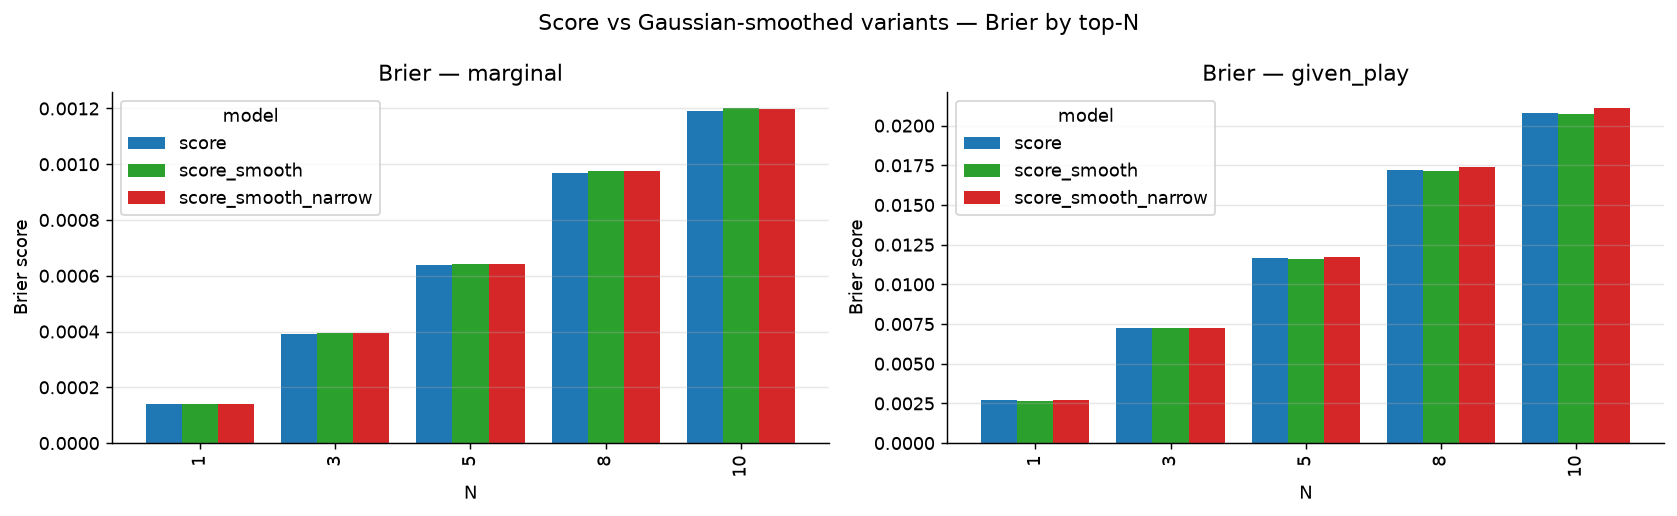

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, metric in zip(axes, ('marginal', 'given_play')):
    sub = brier_sm.xs(metric, level='metric')[list(SMOOTH_MODELS)]
    sub.plot.bar(ax=ax, width=0.8, color=[MODEL_COLORS[m] for m in SMOOTH_MODELS])
    ax.set_title(f'Brier — {metric}')
    ax.set_xlabel('N')
    ax.set_ylabel('Brier score')
    ax.grid(alpha=0.3, axis='y')
plt.suptitle('Score vs Gaussian-smoothed variants — Brier by top-N')
plt.tight_layout()
plt.show()

## Calibration curves — score vs smoothed variants

Reliability diagrams for marginal `P_top{N}` by predicted-probability bin. Smoothing tends to compress extreme probabilities toward the base rate — the visible effect should be that low-probability tails get lifted and high-probability heads get flattened. Narrow smoothing should show a much milder shrinkage than wide smoothing.

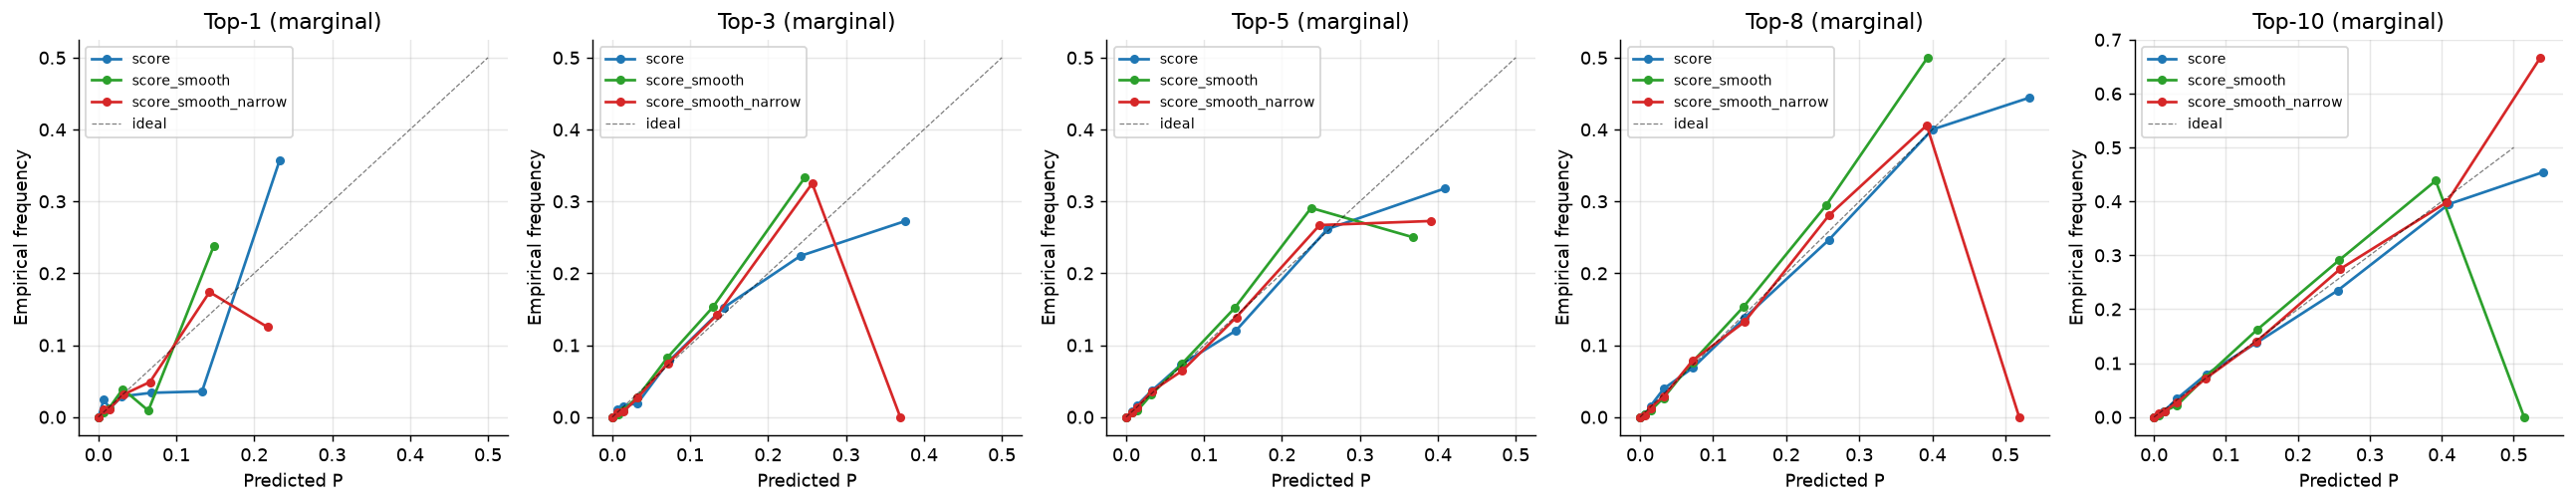

In [9]:
fig, axes = plt.subplots(1, len(N_VALUES), figsize=(4 * len(N_VALUES), 4), sharex=False, sharey=False)
for ax, k in zip(axes, N_VALUES):
    for m in SMOOTH_MODELS:
        sub = df_sm[df_sm['model'] == m]
        p = sub[f'P_top{k}'].to_numpy()
        y = sub[f'in_top{k}'].to_numpy()
        c = cal_curve(p, y)
        ax.plot(c['mean_pred'], c['emp_rate'], 'o-', ms=4, label=m, color=MODEL_COLORS[m])
    ax.plot([0, 0.5], [0, 0.5], 'k--', lw=0.7, alpha=0.5, label='ideal')
    ax.set_title(f'Top-{k} (marginal)')
    ax.set_xlabel('Predicted P')
    ax.set_ylabel('Empirical frequency')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Ranking (AUC) — score vs smoothed variants

Per-tournament ROC-AUC on `in_top{N}` averaged across the 47 tournaments.

For each (tournament, model) the predictor is the aggregated marginal `P_top{k}` (from 100k MC sims), and the label is `in_top{k}` (played AND actual rank ≤ k in the real tournament). AUC measures: does the model assign higher probability to actual top-N finishers than to non-finishers?

Whether smoothing helps AUC depends on whether σ captures **real uncertainty** in the player's true skill distribution. The noise added inside each MC sim is integrated out by the 100k-sim average — what remains in the aggregated probability is a Bayesian-style regularization that treats each historical score as `score ± σ` instead of an exact point sample. If tiebreak/score-bucket variation is more noise than signal, smoothing raises AUC; if that variation carries real skill information, smoothing throws information away.

Mean AUC (higher is better):
         mean                                      std               \
model   score score_smooth score_smooth_narrow   score score_smooth   
N                                                                     
1      0.9971       0.9970              0.9970  0.0037       0.0036   
3      0.9937       0.9964              0.9935  0.0258       0.0060   
5      0.9922       0.9960              0.9920  0.0222       0.0034   
8      0.9892       0.9956              0.9929  0.0259       0.0035   
10     0.9886       0.9952              0.9930  0.0249       0.0029   

                          count                                   
model score_smooth_narrow score score_smooth score_smooth_narrow  
N                                                                 
1                  0.0036    45           47                  47  
3                  0.0257    45           47                  47  
5                  0.0223    45           47                  47  


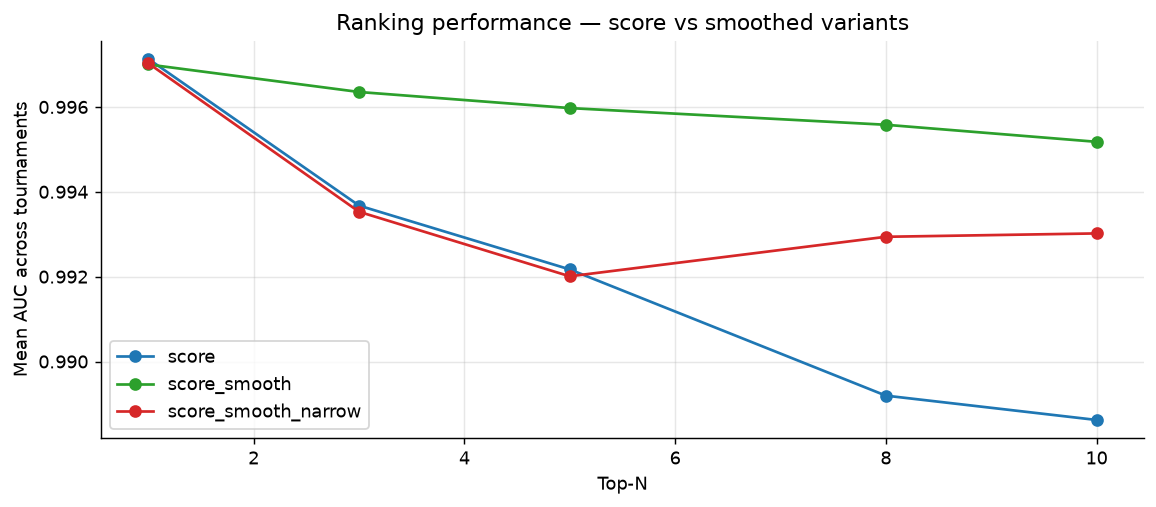

In [10]:
rows_auc_sm = []
for (date, m), sub in df_sm.groupby(['tourn_date', 'model']):
    for k in N_VALUES:
        rows_auc_sm.append({
            'tourn_date': date, 'model': m, 'N': k,
            'auc': _auc(sub[f'P_top{k}'].to_numpy(), sub[f'in_top{k}'].to_numpy()),
        })
auc_sm_df   = pd.DataFrame(rows_auc_sm)
auc_sm_wide = auc_sm_df.groupby(['N', 'model'])['auc'].agg(['mean', 'std', 'count']).unstack('model')
print('Mean AUC (higher is better):')
print(auc_sm_wide.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for m in SMOOTH_MODELS:
    sub = auc_sm_df[auc_sm_df['model'] == m].groupby('N')['auc'].mean()
    ax.plot(sub.index, sub.values, 'o-', label=m, color=MODEL_COLORS[m])
ax.set_xlabel('Top-N')
ax.set_ylabel('Mean AUC across tournaments')
ax.set_title('Ranking performance — score vs smoothed variants')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Where smoothing changes predictions

Scatter of marginal `P_top{N}` for each smoothed variant (y-axis) vs `score` (x-axis) for every player-week. Smoothing should pull extreme predictions toward the base rate: high-`score` predictions get shrunk, near-zero-`score` predictions get lifted. Rows: wide smoothing (top), narrow smoothing (bottom).

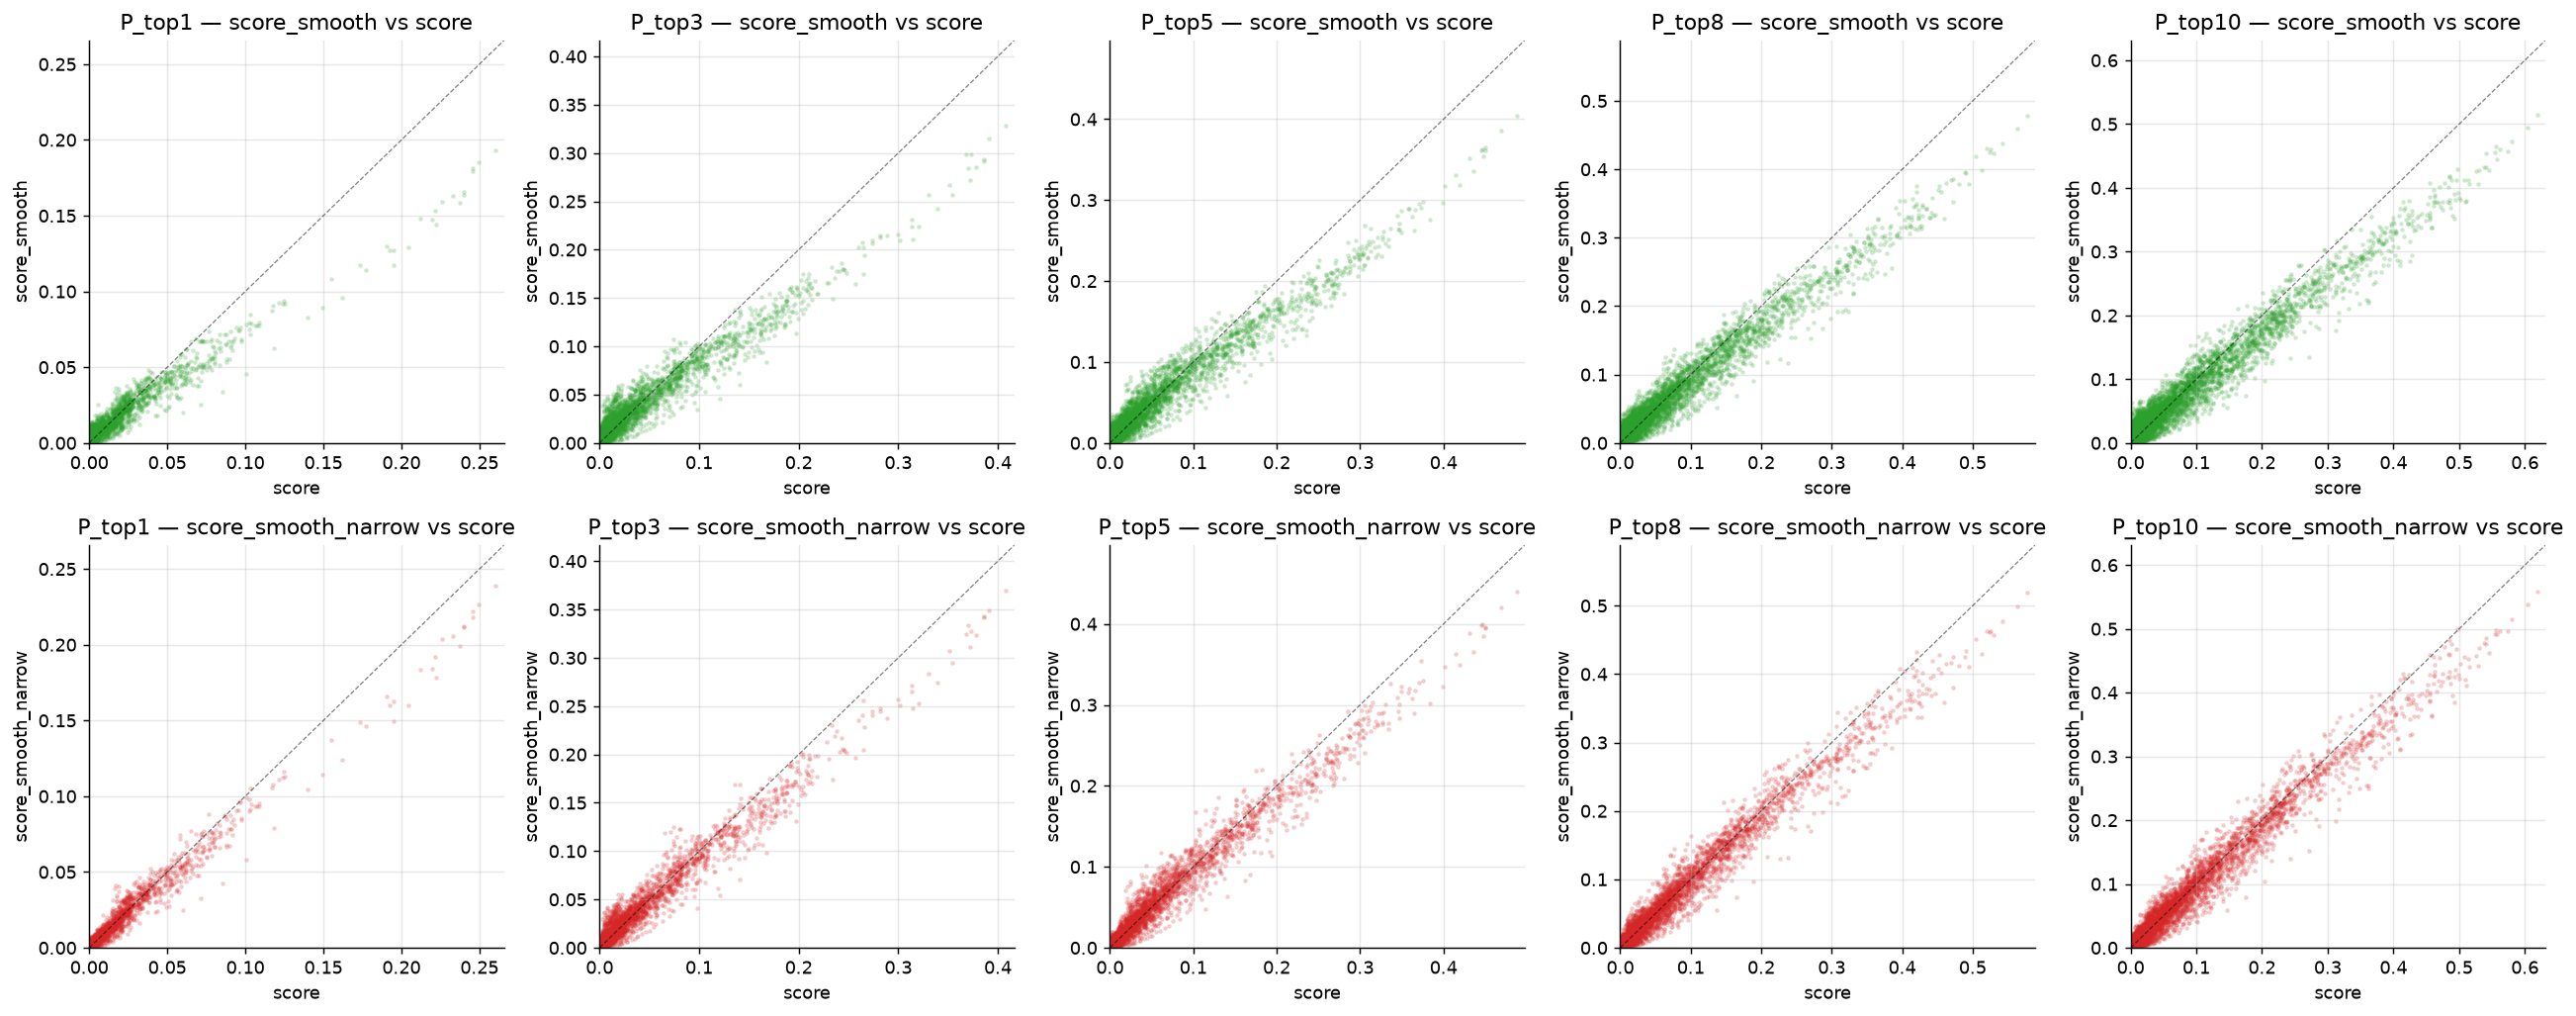

In [11]:
pair = (df_sm.pivot_table(index=['tourn_date', 'username'],
                          columns='model',
                          values=[f'P_top{k}' for k in N_VALUES]))

smoothed = [m for m in SMOOTH_MODELS if m != 'score']
fig, axes = plt.subplots(len(smoothed), len(N_VALUES),
                         figsize=(4 * len(N_VALUES), 4 * len(smoothed)),
                         squeeze=False)
for row, m in enumerate(smoothed):
    for col, k in enumerate(N_VALUES):
        ax = axes[row, col]
        x = pair[(f'P_top{k}', 'score')].to_numpy()
        y = pair[(f'P_top{k}', m)].to_numpy()
        ax.scatter(x, y, s=3, alpha=0.15, color=MODEL_COLORS[m])
        lim = max(np.nanmax(x), np.nanmax(y)) * 1.02
        ax.plot([0, lim], [0, lim], 'k--', lw=0.7, alpha=0.5)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_title(f'P_top{k} — {m} vs score')
        ax.set_xlabel('score'); ax.set_ylabel(m)
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final scorecard — score vs smoothed variants

Brier and AUC together, per top-N cutoff. Lower Brier and higher AUC win. `score` is the incumbent — each smoothed variant needs to justify itself against both `score` and the other smoothed variant.

In [12]:
brier_scorecard = brier_sm[list(SMOOTH_MODELS) + ['best']].copy()

auc_scorecard = auc_sm_wide['mean'][list(SMOOTH_MODELS)].copy()
auc_scorecard['best'] = auc_scorecard.idxmax(axis=1)

print('=== Brier winners (marginal + given_play) — lower is better ===')
print(brier_scorecard.round(6))
print()
print('=== AUC winners (marginal, per N) — higher is better ===')
print(auc_scorecard.round(4))

=== Brier winners (marginal + given_play) — lower is better ===
model             score  score_smooth  score_smooth_narrow          best
metric     N                                                            
given_play 1   0.002702      0.002662             0.002687  score_smooth
           3   0.007235      0.007220             0.007265  score_smooth
           5   0.011689      0.011621             0.011750  score_smooth
           8   0.017174      0.017140             0.017382  score_smooth
           10  0.020808      0.020760             0.021093  score_smooth
marginal   1   0.000141      0.000140             0.000140  score_smooth
           3   0.000391      0.000394             0.000393         score
           5   0.000639      0.000642             0.000641         score
           8   0.000968      0.000977             0.000974         score
           10  0.001192      0.001201             0.001198         score

=== AUC winners (marginal, per N) — higher is better ===
mo